# Trabajo Series Temporales

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import polars as pl


# 🏗️ Data loading

In [3]:
STORAGE_PATH = "./competition_package/datasets/"
training_data = pl.read_parquet(STORAGE_PATH+"/train.parquet")
testing_data = pl.read_parquet(STORAGE_PATH+"/valid.parquet")

In [4]:
print(training_data.shape)

(10721000, 37)


In [5]:
print(training_data.head(1_001))

shape: (1_001, 37)
┌────────┬─────────────┬────────────┬──────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ seq_ix ┆ step_in_seq ┆ need_predi ┆ p0       ┆ … ┆ dv2       ┆ dv3       ┆ t0        ┆ t1        │
│ ---    ┆ ---         ┆ ction      ┆ ---      ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ i64    ┆ i64         ┆ ---        ┆ f64      ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
│        ┆             ┆ i8         ┆          ┆   ┆           ┆           ┆           ┆           │
╞════════╪═════════════╪════════════╪══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0      ┆ 0           ┆ 0          ┆ 1.077446 ┆ … ┆ -0.368215 ┆ -0.503497 ┆ -0.564226 ┆ 1.864018  │
│ 0      ┆ 1           ┆ 0          ┆ 1.10014  ┆ … ┆ -1.563974 ┆ -1.92999  ┆ -0.239079 ┆ 2.168843  │
│ 0      ┆ 2           ┆ 0          ┆ 1.10014  ┆ … ┆ -0.402838 ┆ 1.042579  ┆ 2.237778  ┆ 2.459723  │
│ 0      ┆ 3           ┆ 0          ┆ 0.955471 ┆ … ┆ 1.258192  ┆ 0.91407

# 🔎 EDA / Data inspection

## Formato de datos con sentido

Vamos a construir un formato de datos que tenga sentido (el que nos dan es un poco una locura...)

Hemos definido una estructura principal, `SequencePanelData`, que nos permite trabajar de forma ordenada con datos secuenciales organizados por múltiples series (panel). Con esta clase podemos acceder fácilmente a cada secuencia, separar periodos de *warm-up* y predicción, transformar los datos a formatos útiles (como arrays de NumPy o formato largo para visualización) y preparar directamente los inputs para modelos tanto clásicos como de deep learning.


Además, incluimos una clase opcional `SequenceTorchDataset`, pensada para integrarse con PyTorch. Esta clase nos facilita convertir cada secuencia en tensores listos para entrenamiento, incluyendo máscaras que distinguen entre las partes observadas y las que queremos predecir.


In [6]:
from src import SequencePanelData, SequenceTorchDataset

/home/adrian/git_repos/LOB-predictorium/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'abstractmethod' is not defined

shape: (21, 6)
┌────────┬────────┬──────────────┬────────────────┬──────────┬──────────┐
│ seq_ix ┆ n_rows ┆ n_pred_steps ┆ n_warmup_steps ┆ step_min ┆ step_max │
│ ---    ┆ ---    ┆ ---          ┆ ---            ┆ ---      ┆ ---      │
│ i64    ┆ u32    ┆ i64          ┆ i64            ┆ i64      ┆ i64      │
╞════════╪════════╪══════════════╪════════════════╪══════════╪══════════╡
│ 0      ┆ 1000   ┆ 901          ┆ 99             ┆ 0        ┆ 999      │
│ 1      ┆ 1000   ┆ 901          ┆ 99             ┆ 0        ┆ 999      │
│ 2      ┆ 1000   ┆ 901          ┆ 99             ┆ 0        ┆ 999      │
│ 3      ┆ 1000   ┆ 901          ┆ 99             ┆ 0        ┆ 999      │
│ 4      ┆ 1000   ┆ 901          ┆ 99             ┆ 0        ┆ 999      │
│ …      ┆ …      ┆ …            ┆ …              ┆ …        ┆ …        │
│ 16     ┆ 1000   ┆ 901          ┆ 99             ┆ 0        ┆ 999      │
│ 17     ┆ 1000   ┆ 901          ┆ 99             ┆ 0        ┆ 999      │
│ 18     ┆ 1000   ┆ 901

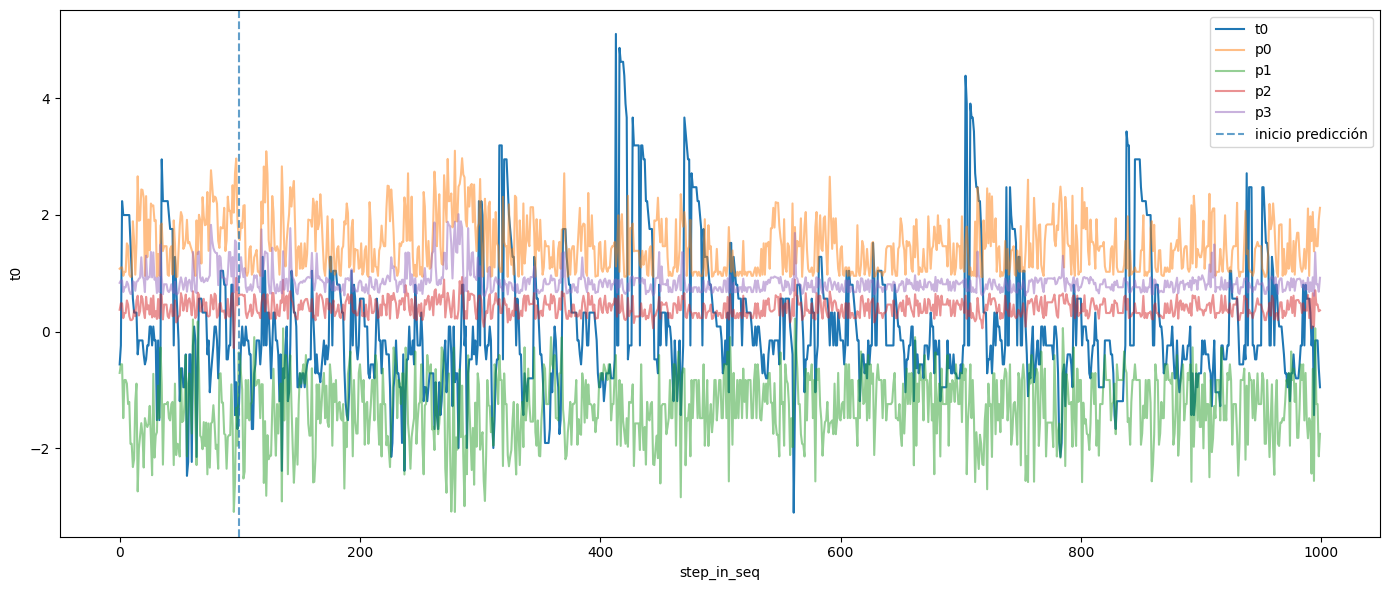

In [ ]:
N_TS = 21

panel = SequencePanelData(
    training_data[:N_TS * 1_000],
    target_cols=("t0", "t1"),
    expected_seq_len=1000,
)

print(panel.overview())
panel.plot_sequence(0, target="t0")


## Forecasting EDA


### Ver las variables objetivo

In [14]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



def plot_targets_heatmap(panel):
    data = panel.stack_all_sequences()

    X = data["X"]  # no lo usamos aquí, pero queda claro el formato
    y = data["y"]  # shape: [N, T, 2]

    t0 = y[:, :, 0]
    t1 = y[:, :, 1]

    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    im0 = axes[0].imshow(
        t0,
        aspect="auto",
        interpolation="nearest"
    )
    axes[0].set_title("Heatmap de t0 (todas las secuencias)")
    axes[0].set_ylabel("seq_ix")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(
        t1,
        aspect="auto",
        interpolation="nearest"
    )
    axes[1].set_title("Heatmap de t1 (todas las secuencias)")
    axes[1].set_xlabel("step_in_seq")
    axes[1].set_ylabel("seq_ix")
    plt.colorbar(im1, ax=axes[1])

    plt.tight_layout()
    plt.show()

def plot_sequence_targets(panel, seq_ix):
    """
    Visualiza t0 y t1 para una secuencia concreta.
    Marca claramente la zona de predicción.
    """

    seq = panel.sequence_df(seq_ix)

    t = seq.get_column(panel.step_col).to_numpy()
    t0 = seq.get_column("t0").to_numpy()
    t1 = seq.get_column("t1").to_numpy()
    mask = seq.get_column(panel.warmup_col).to_numpy().astype(bool)

    plt.figure(figsize=(14, 5))

    # series
    plt.plot(t, t0, label="t0")
    plt.plot(t, t1, label="t1")

    # inicio de predicción
    if mask.any():
        start_pred = np.argmax(mask)

        # línea vertical
        plt.axvline(t[start_pred], linestyle="--", alpha=0.7)

        # sombreado zona predicción
        plt.fill_between(
            t,
            min(t0.min(), t1.min()),
            max(t0.max(), t1.max()),
            where=mask,
            alpha=0.1,
        )

    plt.title(f"Secuencia {seq_ix} — t0 vs t1")
    plt.xlabel("step_in_seq")
    plt.ylabel("valor")
    plt.legend()

    plt.tight_layout()
    plt.show()

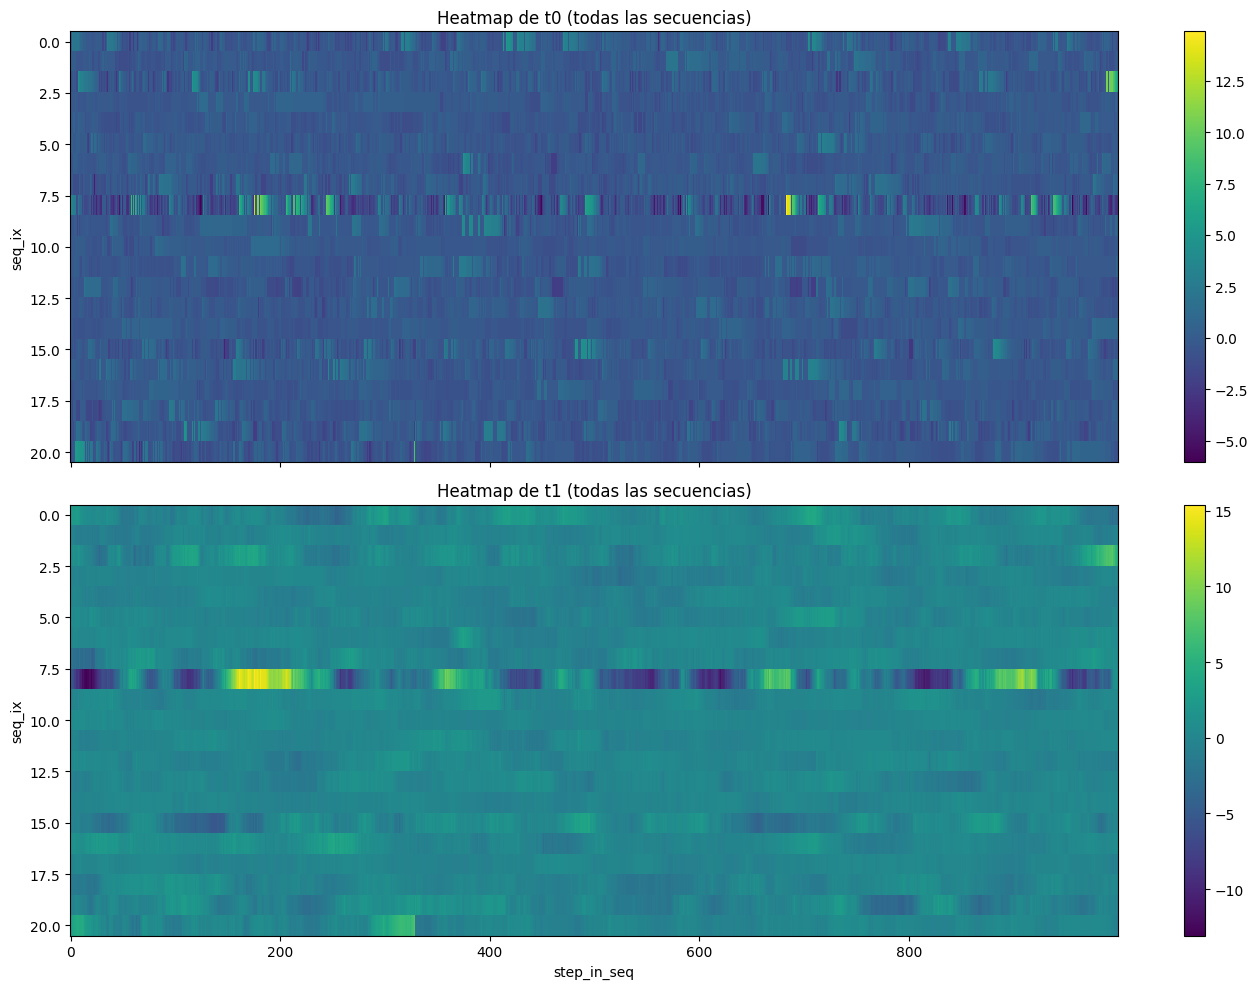

In [15]:
plot_targets_heatmap(panel)

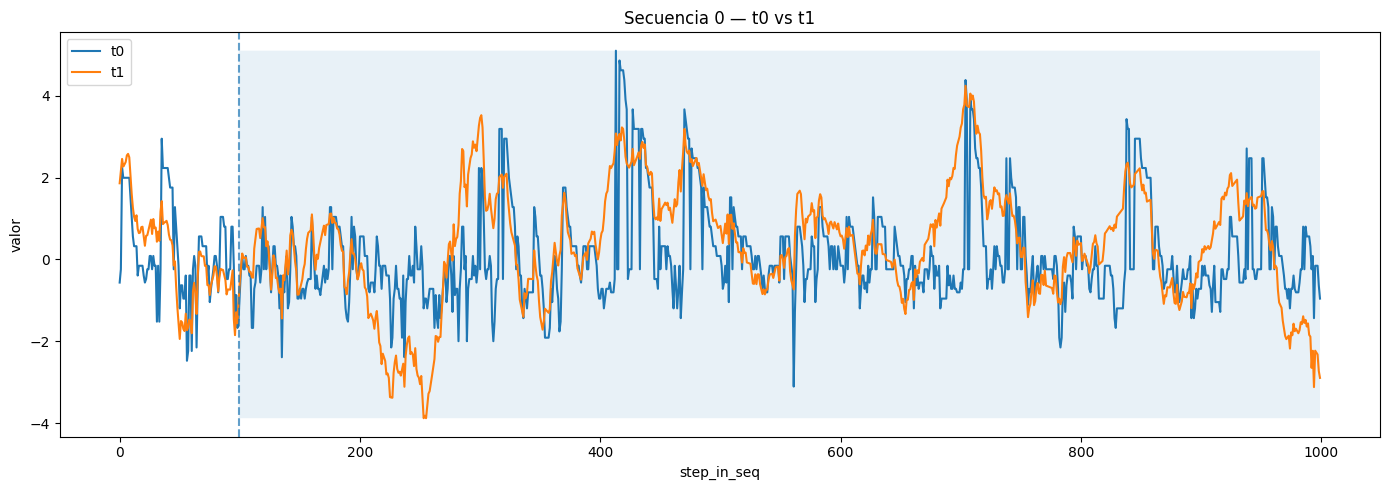

In [16]:
plot_sequence_targets(panel, 0)

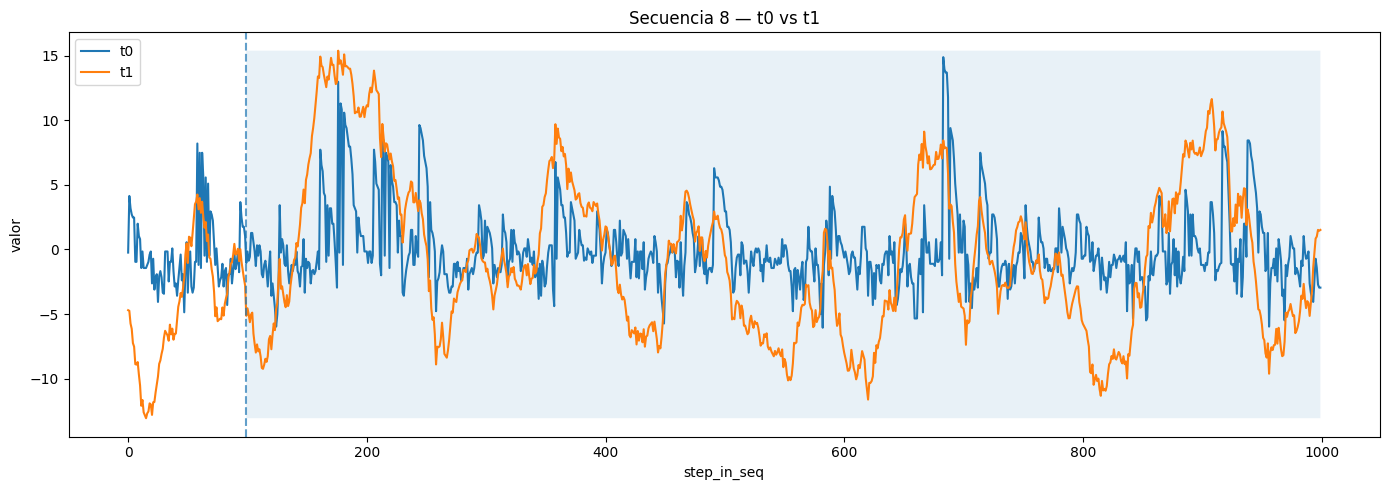

In [17]:
plot_sequence_targets(panel, 8)

## Correlacion

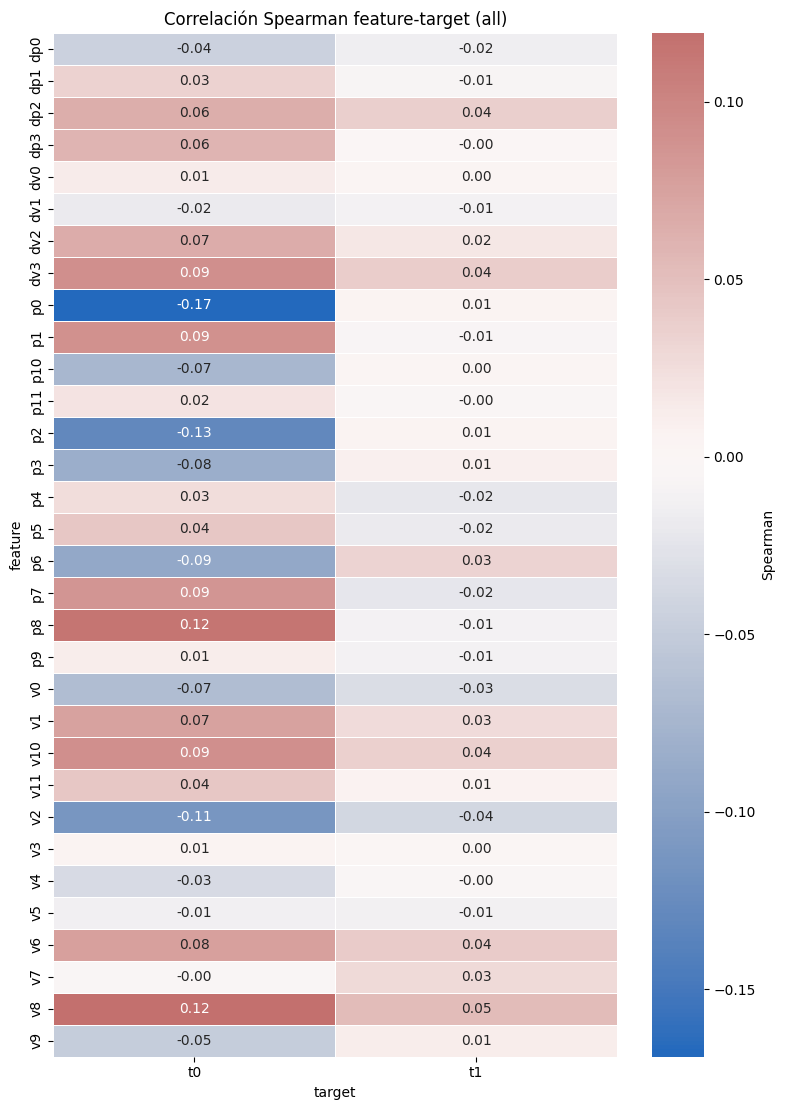

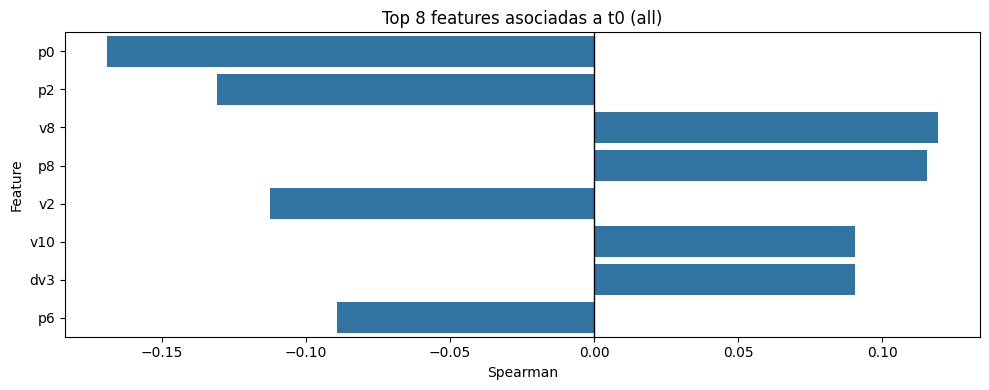

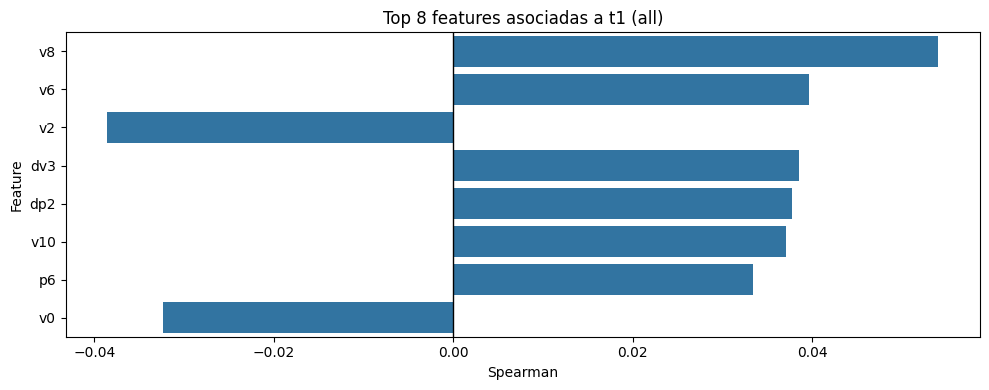

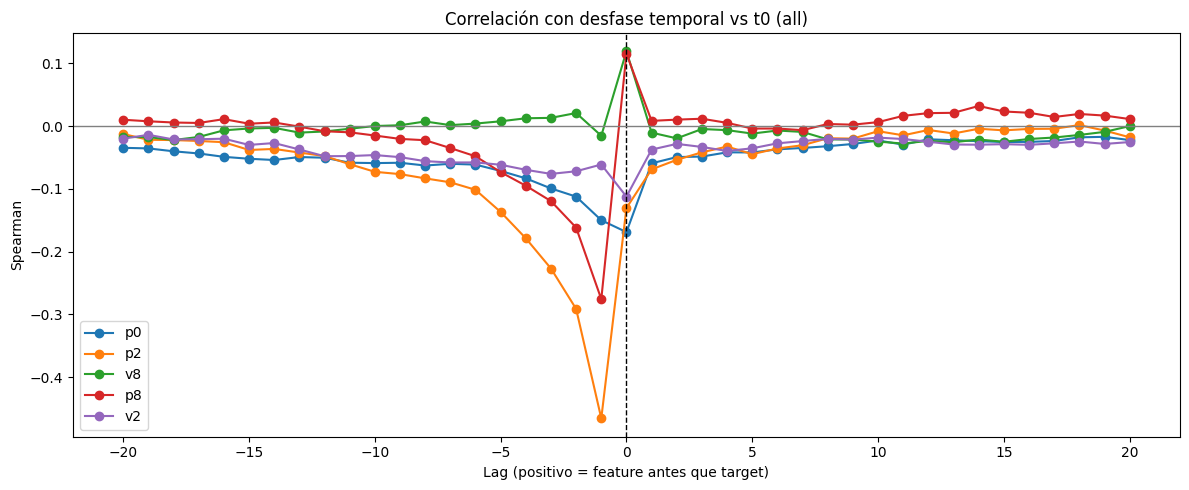

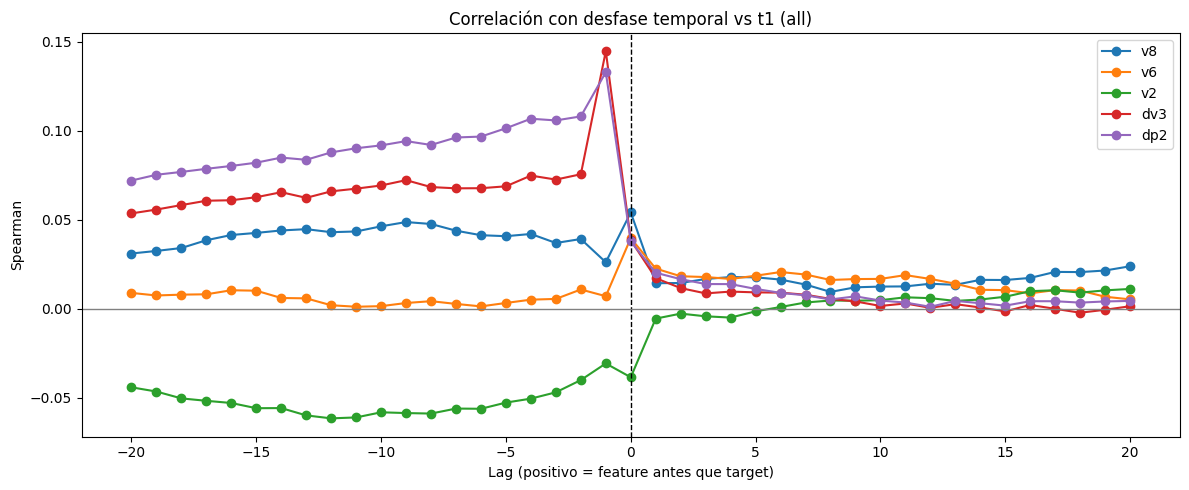

feature,target,pearson,spearman,abs_pearson,abs_spearman,n
str,str,f64,f64,f64,f64,i64
"""p0""","""t0""",-0.089785,-0.16901,0.089785,0.16901,21000
"""p2""","""t0""",-0.109681,-0.130601,0.109681,0.130601,21000
"""v8""","""t0""",0.097589,0.119412,0.097589,0.119412,21000
"""p8""","""t0""",0.037967,0.115309,0.037967,0.115309,21000
"""v2""","""t0""",-0.08599,-0.112394,0.08599,0.112394,21000
…,…,…,…,…,…,…
"""p10""","""t1""",-0.054428,0.003353,0.054428,0.003353,21000
"""v4""","""t1""",-0.002928,-0.002523,0.002928,0.002523,21000
"""dv0""","""t1""",-0.00202,0.002465,0.00202,0.002465,21000


In [12]:
from src import analyze_panel_feature_target_relations

analyze_panel_feature_target_relations(panel, segment="all")

## Seasonality

/home/adrian/git_repos/LOB-predictorium/src/seasonality.py:183: RuntimeWarning: divide by zero encountered in divide
  periods = np.where(valid, 1.0 / freqs, np.nan)


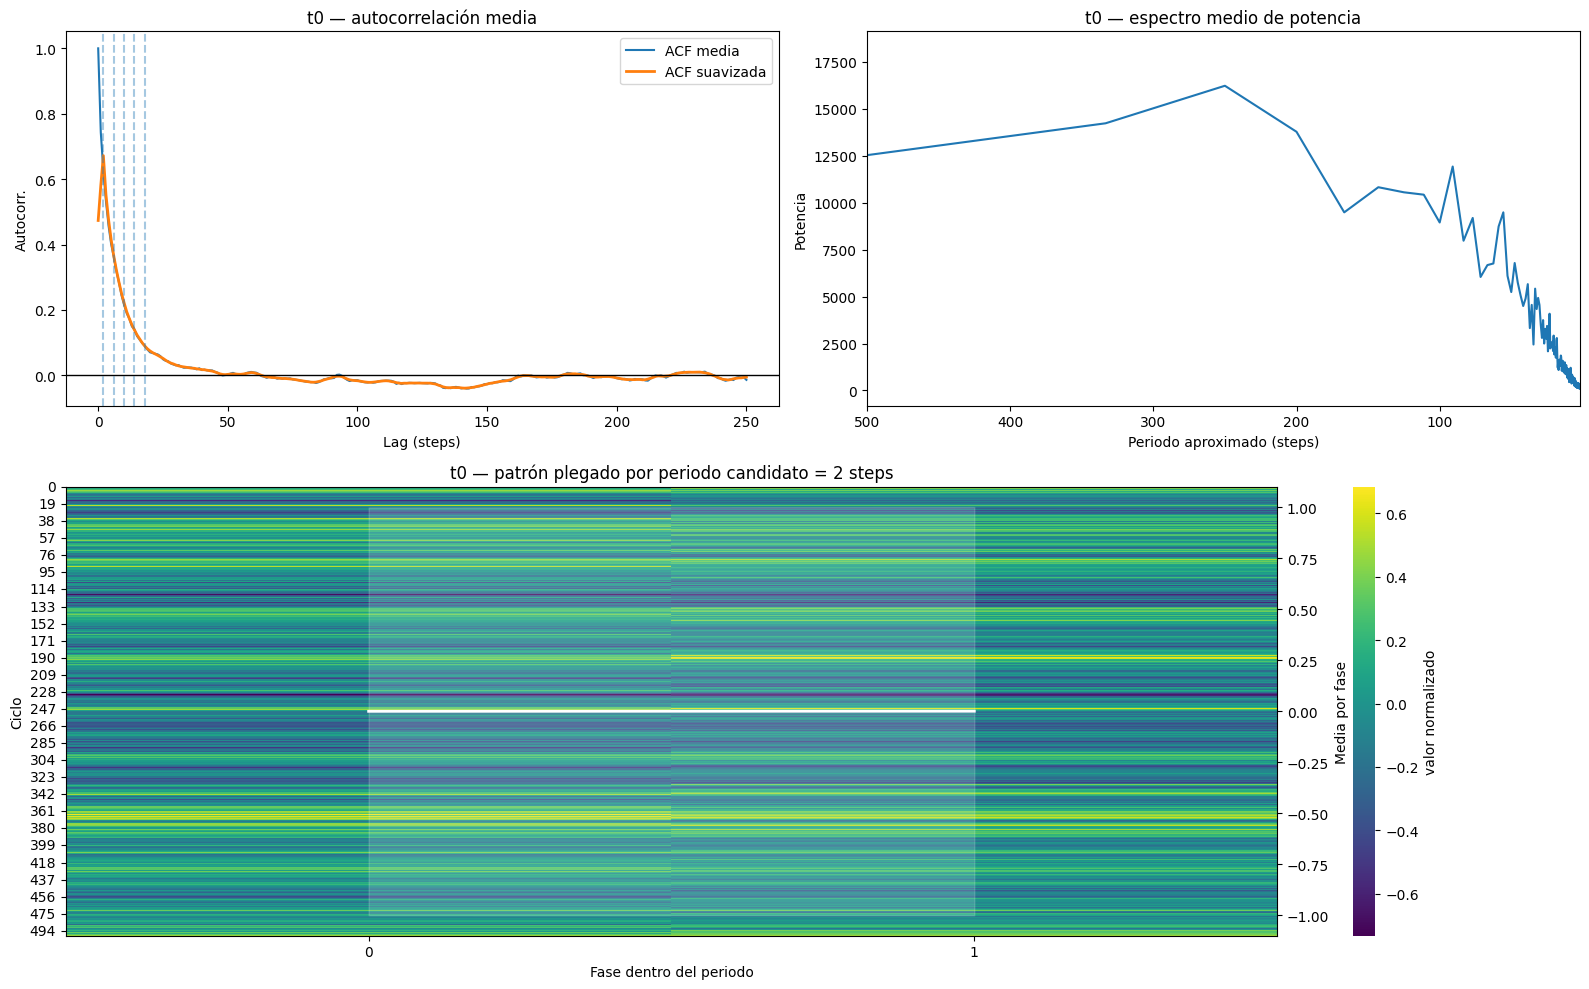

/home/adrian/git_repos/LOB-predictorium/src/seasonality.py:183: RuntimeWarning: divide by zero encountered in divide
  periods = np.where(valid, 1.0 / freqs, np.nan)


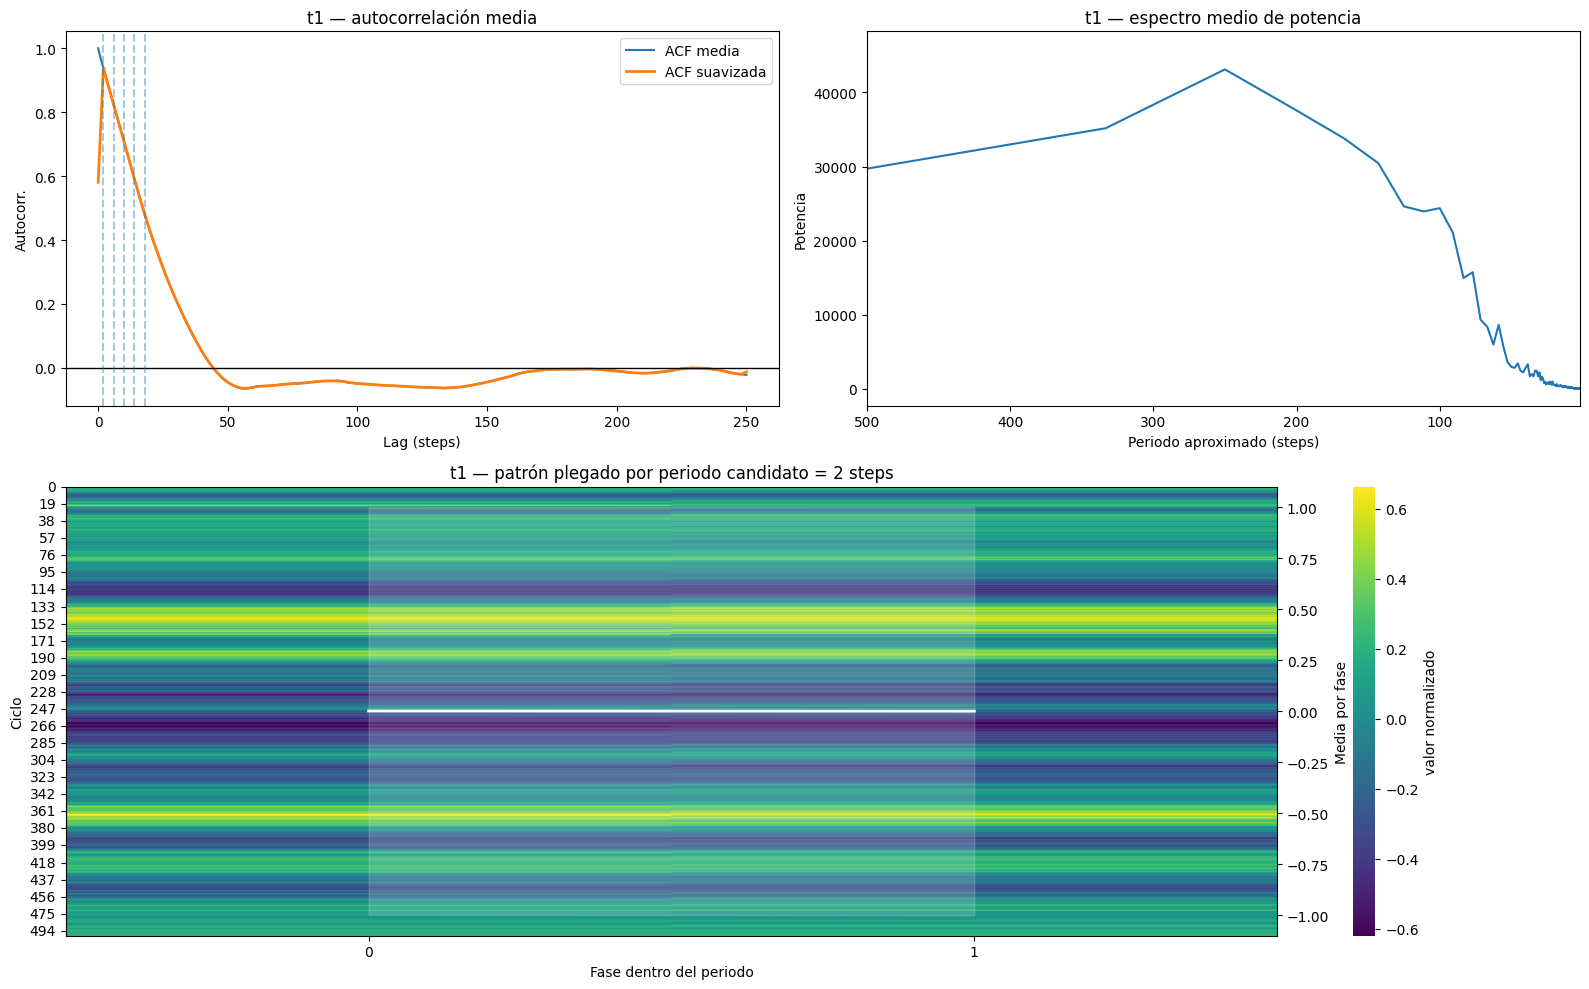

variable,method,period_steps,score,cycles_in_1000
str,str,i64,f64,f64
"""t0""","""acf""",2,0.671891,500.0
"""t0""","""acf""",6,0.365441,166.666667
"""t0""","""acf""",10,0.221826,100.0
"""t0""","""acf""",14,0.138654,71.428571
"""t0""","""acf""",18,0.089498,55.555556
…,…,…,…,…
"""t1""","""spectrum""",1000,45958.975885,1.0
"""t1""","""spectrum""",200,37577.867253,5.0
"""t1""","""spectrum""",100,24374.747963,10.0


In [13]:
from src import analyze_panel_seasonality
analyze_panel_seasonality(panel)

## Extracción de hiperparámetros para S/ARIMA/X

In [ ]:
from src import sarimax_panel_analysis,  SarimaxAnalyzer

df_params_t0 = sarimax_panel_analysis(panel, target="t0")
df_params_t1 = sarimax_panel_analysis(panel, target="t1")

In [ ]:
df_params_t1

seq_ix,target,p,d,q,P,D,Q,s,aic,n_points,n_fits,status
i64,str,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,str
0,"""t1""",1,0,2,0,0,0,0,300.453992,1000,36,"""ok_0_fallos"""
1,"""t1""",2,0,2,0,0,0,0,-572.686382,1000,36,"""ok_0_fallos"""
2,"""t1""",1,0,1,0,0,0,0,779.703503,1000,36,"""ok_0_fallos"""
3,"""t1""",1,0,1,0,0,0,0,-779.376964,1000,36,"""ok_0_fallos"""
4,"""t1""",1,0,1,0,0,0,0,-843.441704,1000,36,"""ok_0_fallos"""
…,…,…,…,…,…,…,…,…,…,…,…,…
95,"""t1""",1,0,2,0,0,0,0,-1409.880746,1000,36,"""ok_0_fallos"""
96,"""t1""",1,0,2,0,0,0,0,-815.115234,1000,36,"""ok_0_fallos"""
97,"""t1""",2,0,2,0,0,0,0,-287.831726,1000,36,"""ok_0_fallos"""


In [ ]:
analyzer = SarimaxAnalyzer(df_params_t0, df_params_t1)


--- ANÁLISIS CUALITATIVO ---

Interpretación para [Target 0]:
- La estructura predominante es (2, 0, 2).
- La mayoría de las series no presentan componentes estacionales claros.
- Tasa de éxito en el ajuste: 100.00%


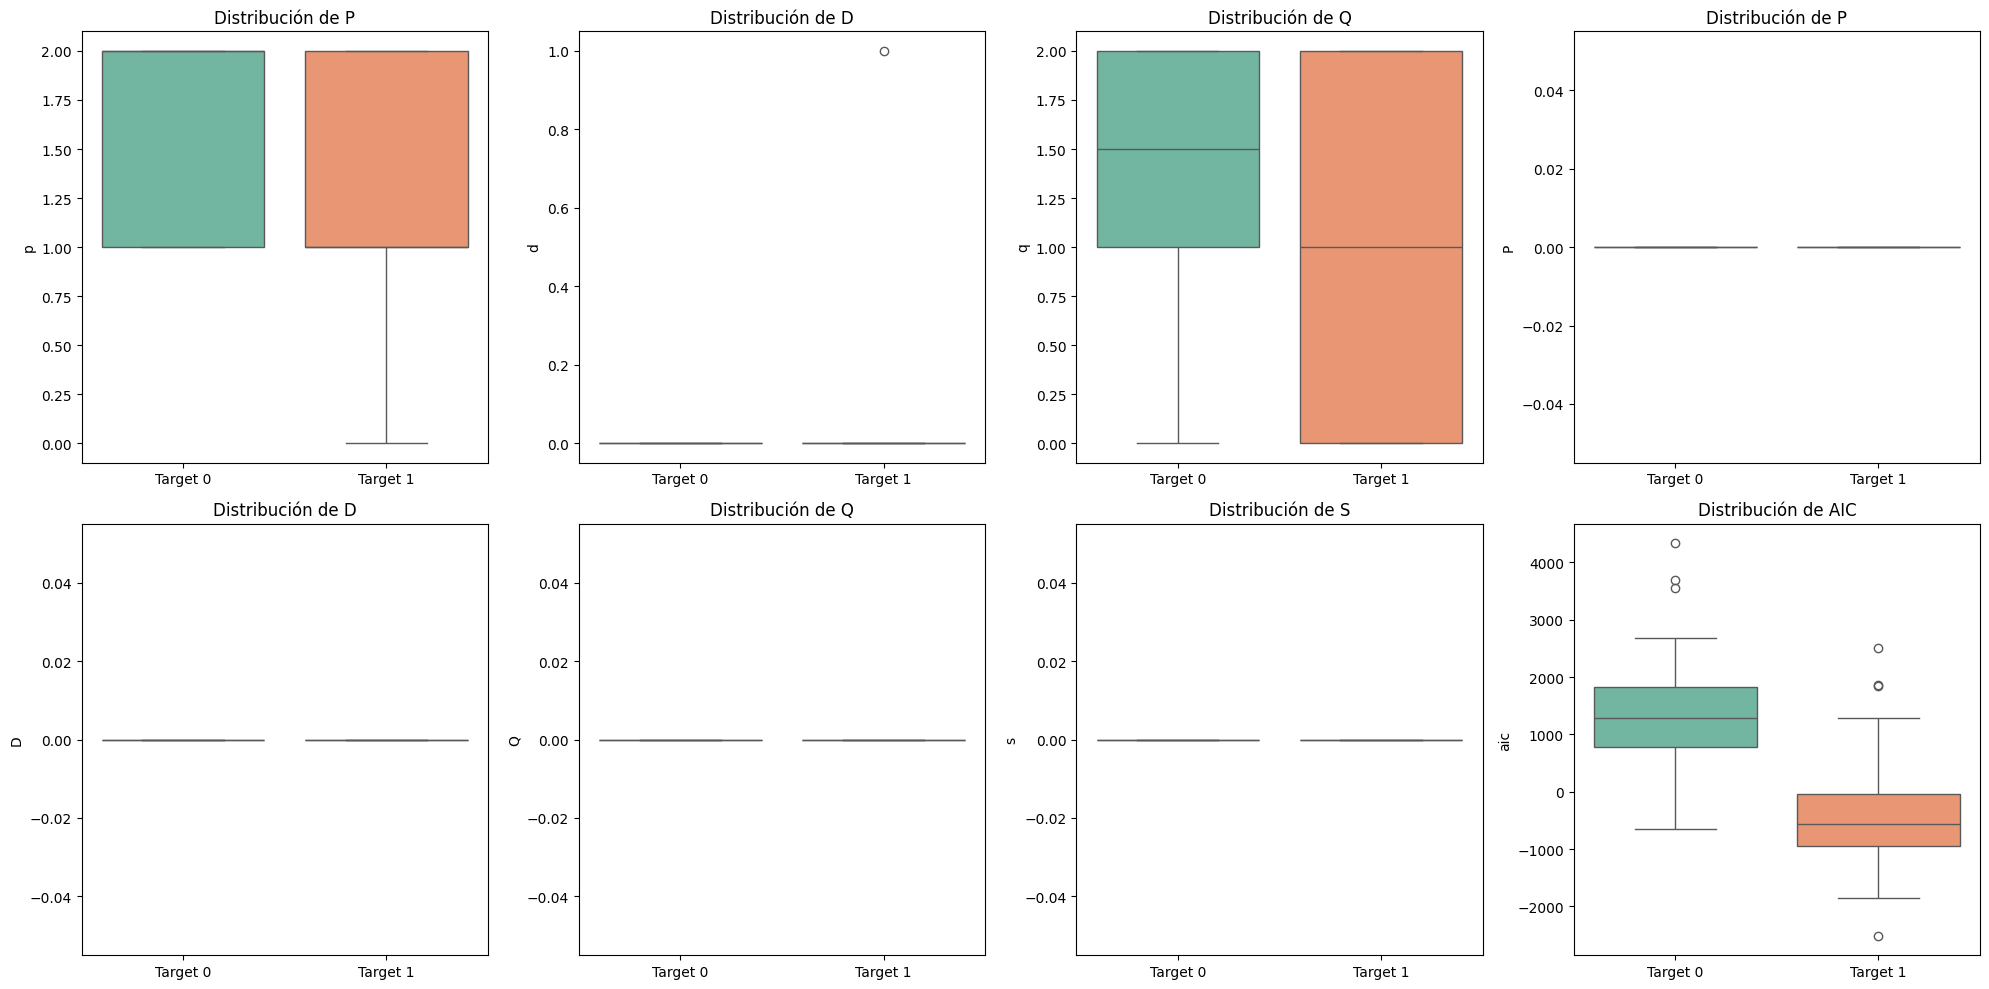

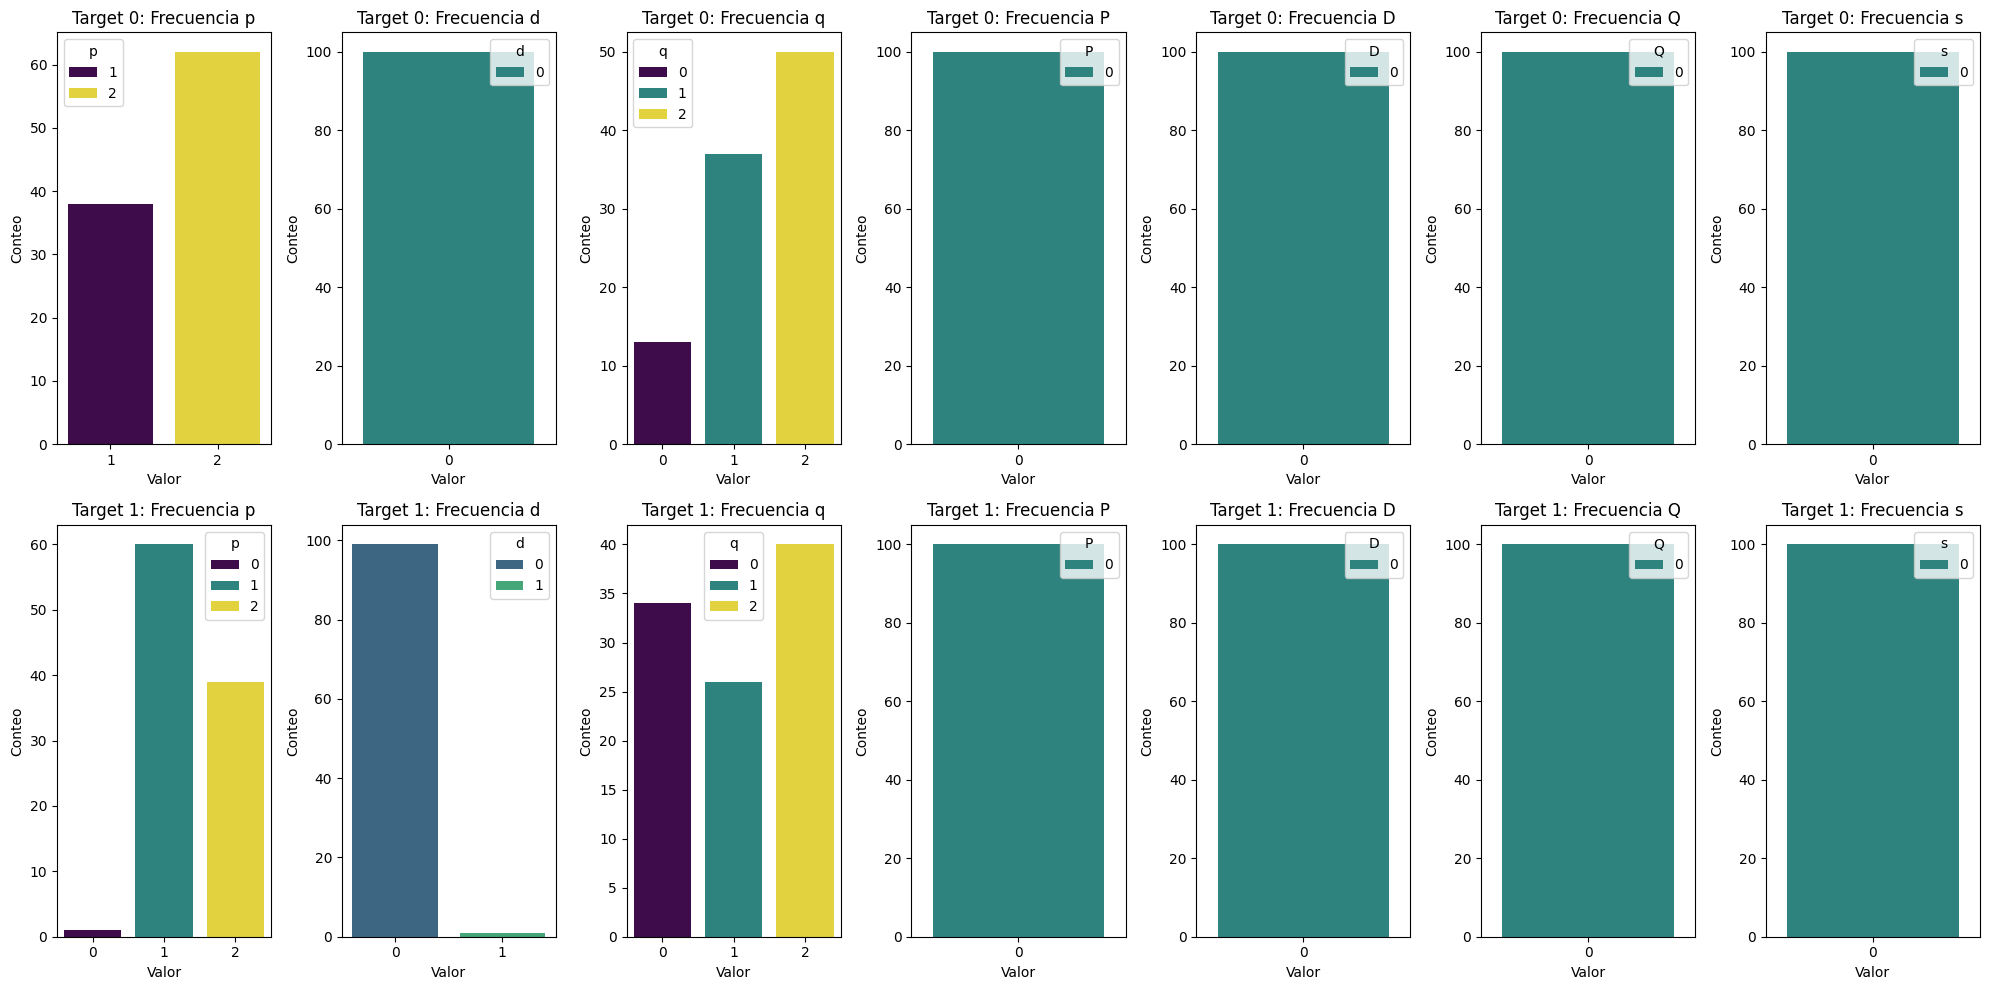

<string>:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<string>:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


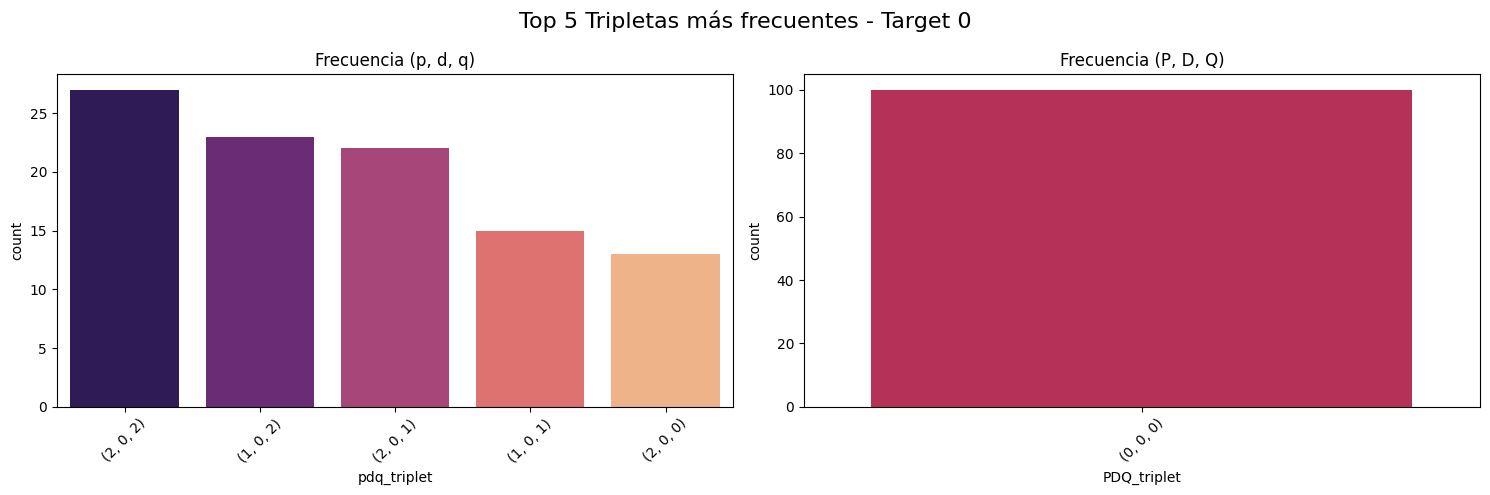

<string>:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<string>:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


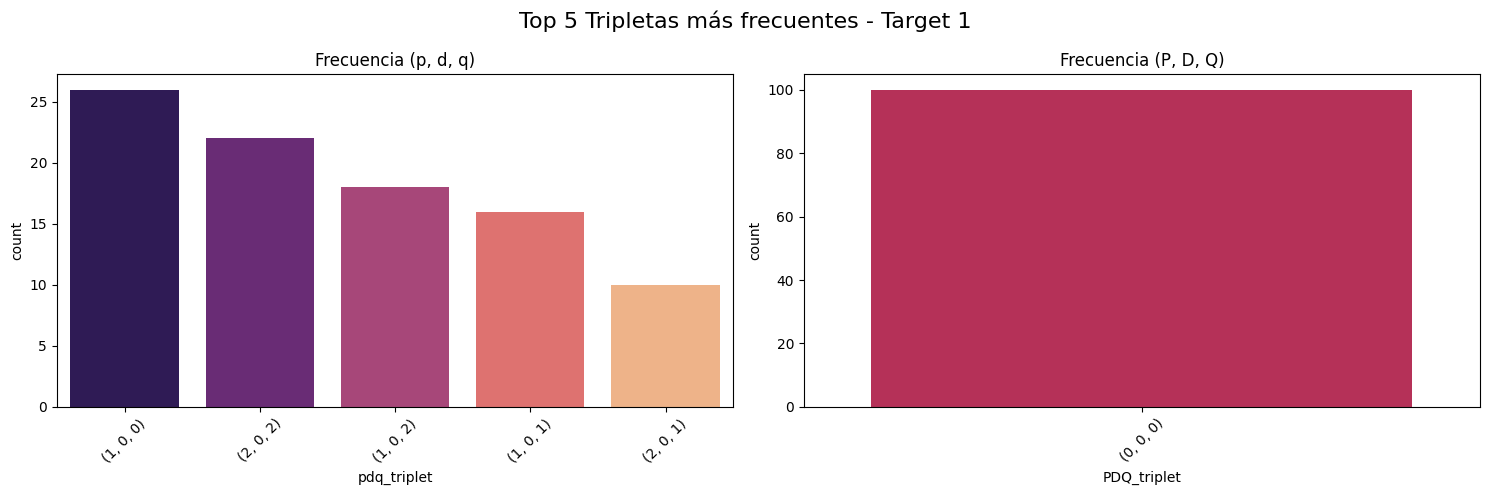


Interpretación para [Target 1]:
- La estructura predominante es (1, 0, 2).
- La mayoría de las series no presentan componentes estacionales claros.
- Tasa de éxito en el ajuste: 100.00%


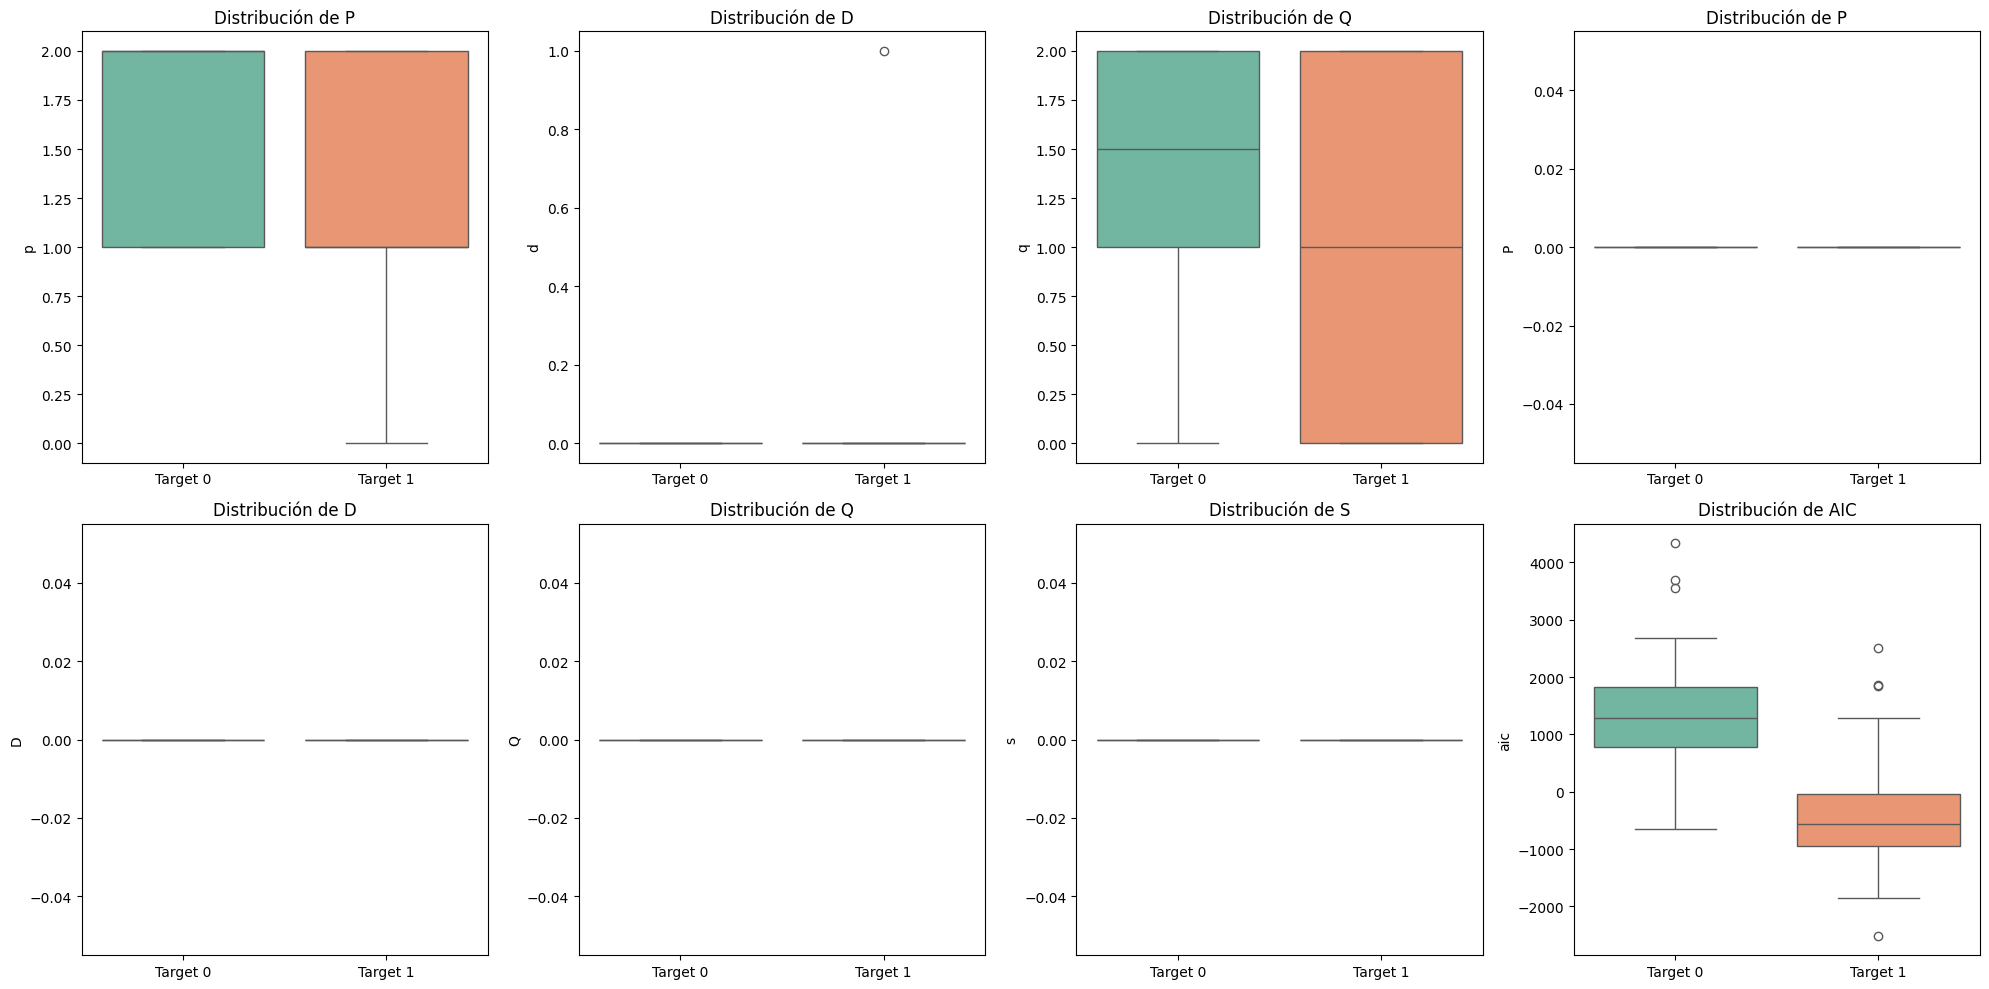

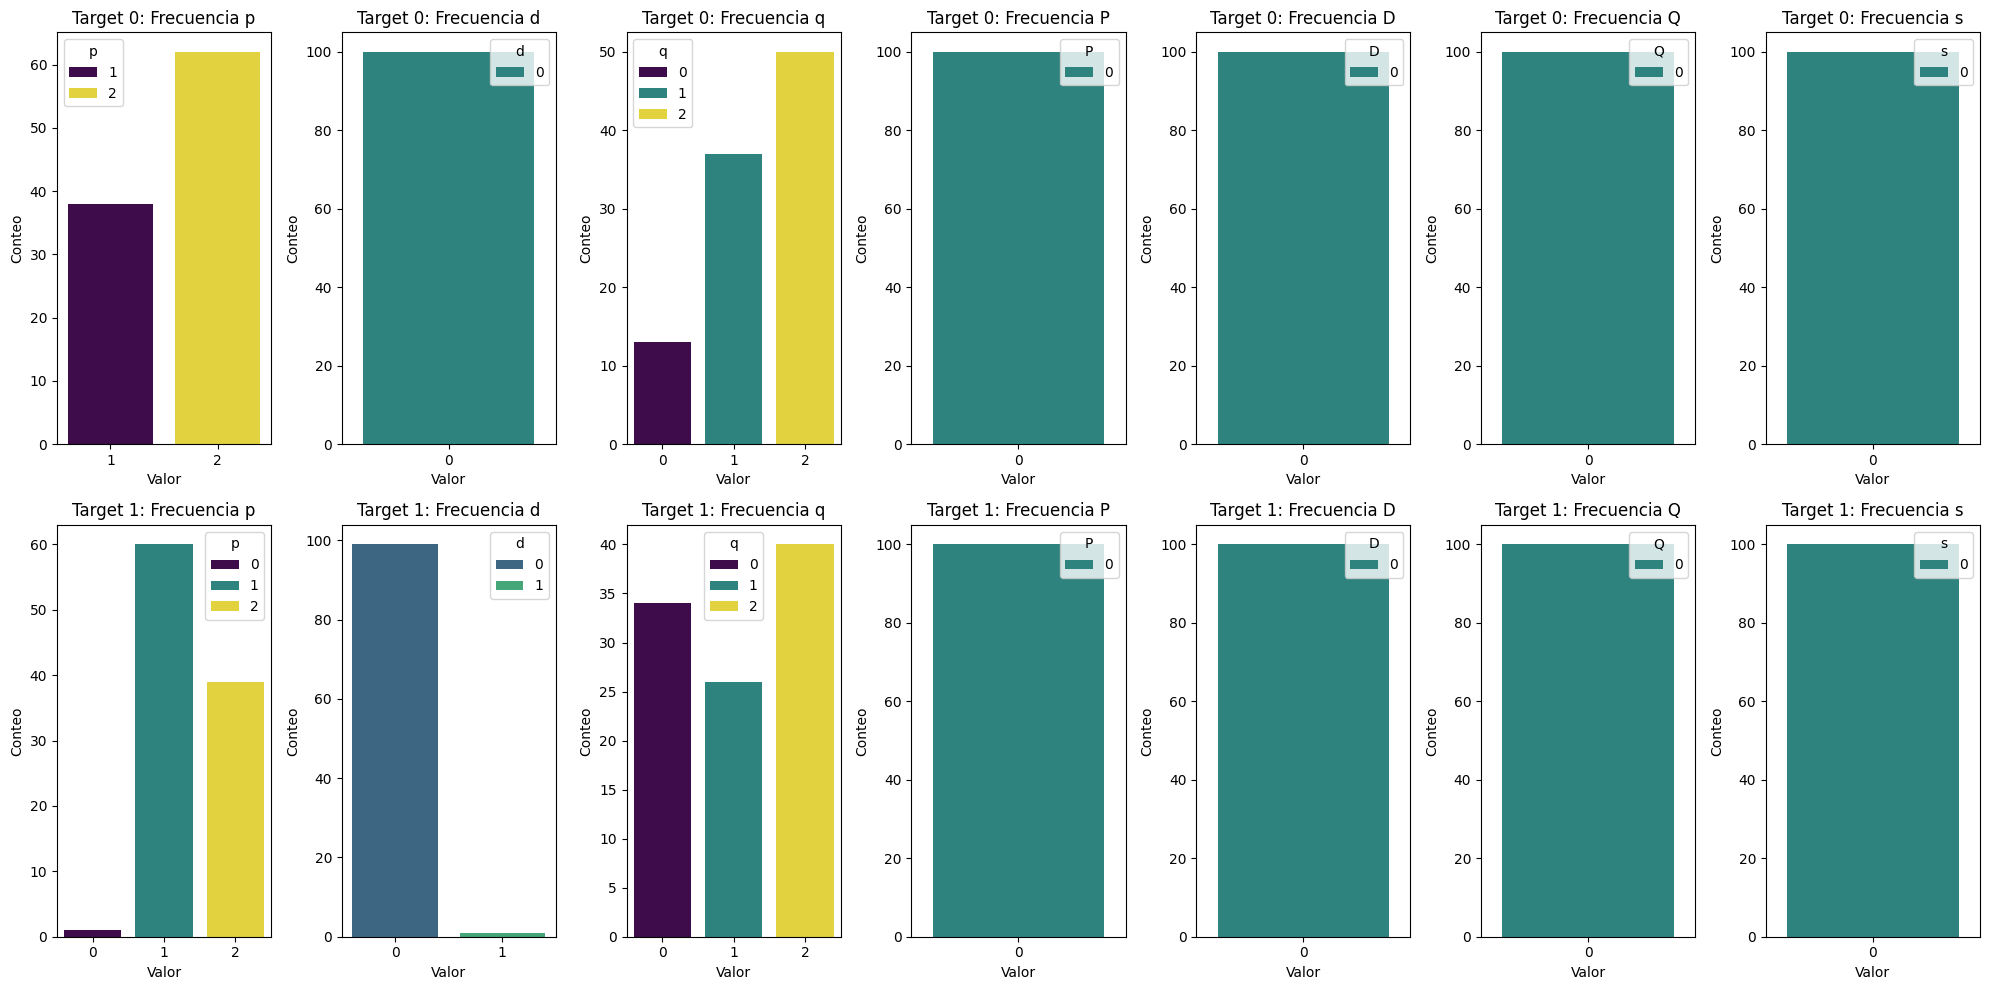

<string>:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<string>:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


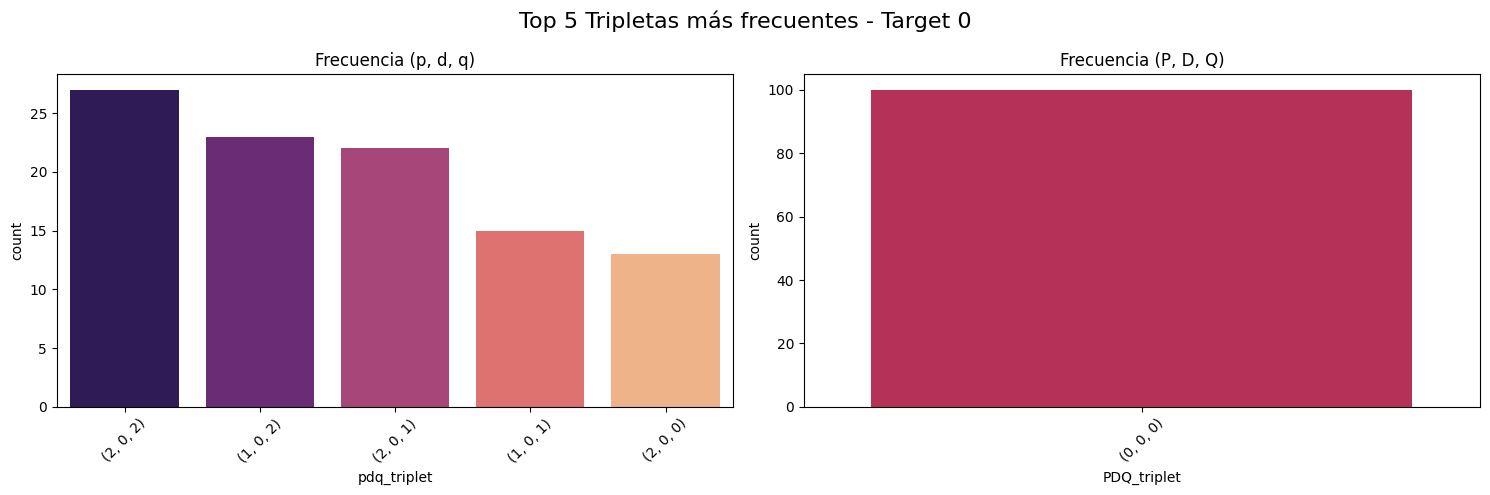

<string>:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<string>:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


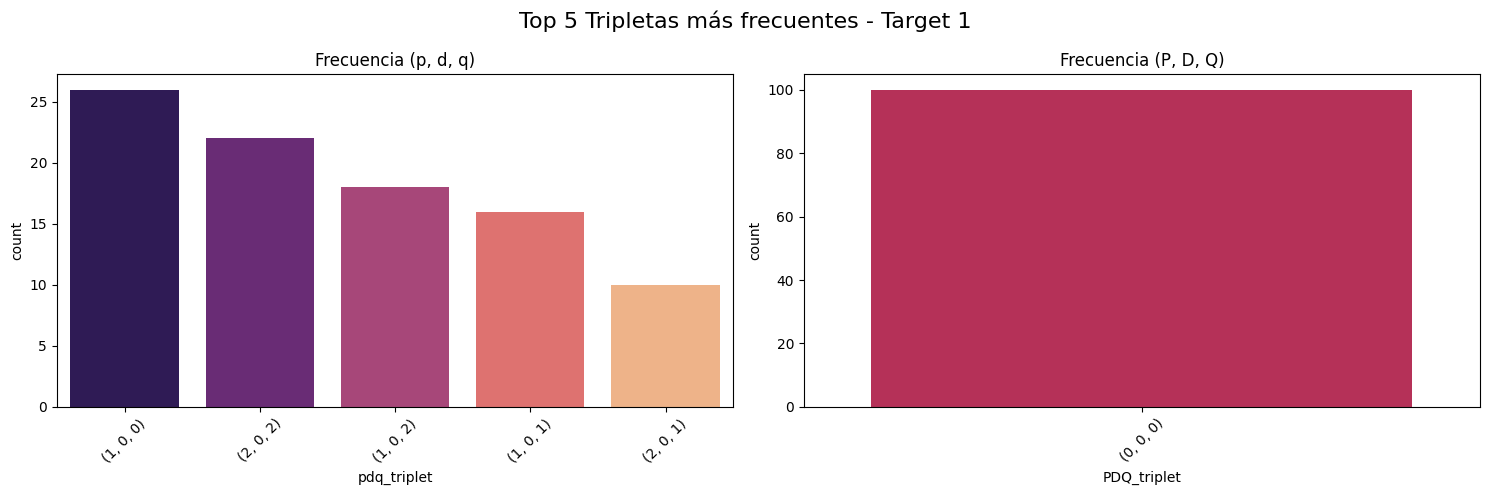

In [ ]:
analyzer.qualitative_summary()

# 🤖 Forecasting models

In [8]:
testPanel = SequencePanelData(
    testing_data[:(N_TS//2) * 1_000],
    target_cols=("t0", "t1"),
    expected_seq_len=1000,
)

## ARIMAx

In [19]:
from src import MySarimaModel
arima = MySarimaModel(panel, testPanel, (2,0,2), (1,0,0))
arima = arima.fit()

/home/adrian/git_repos/LOB-predictorium/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/adrian/git_repos/LOB-predictorium/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


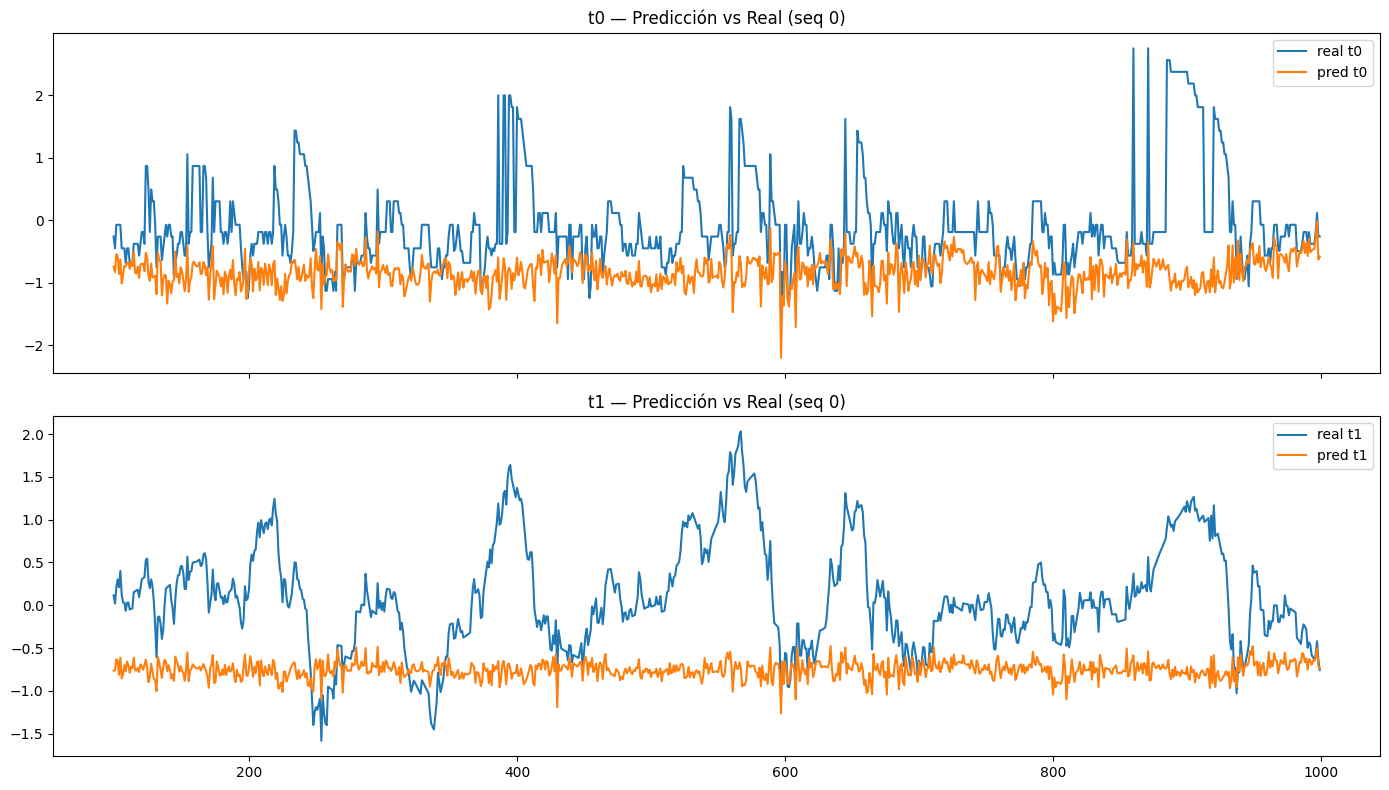

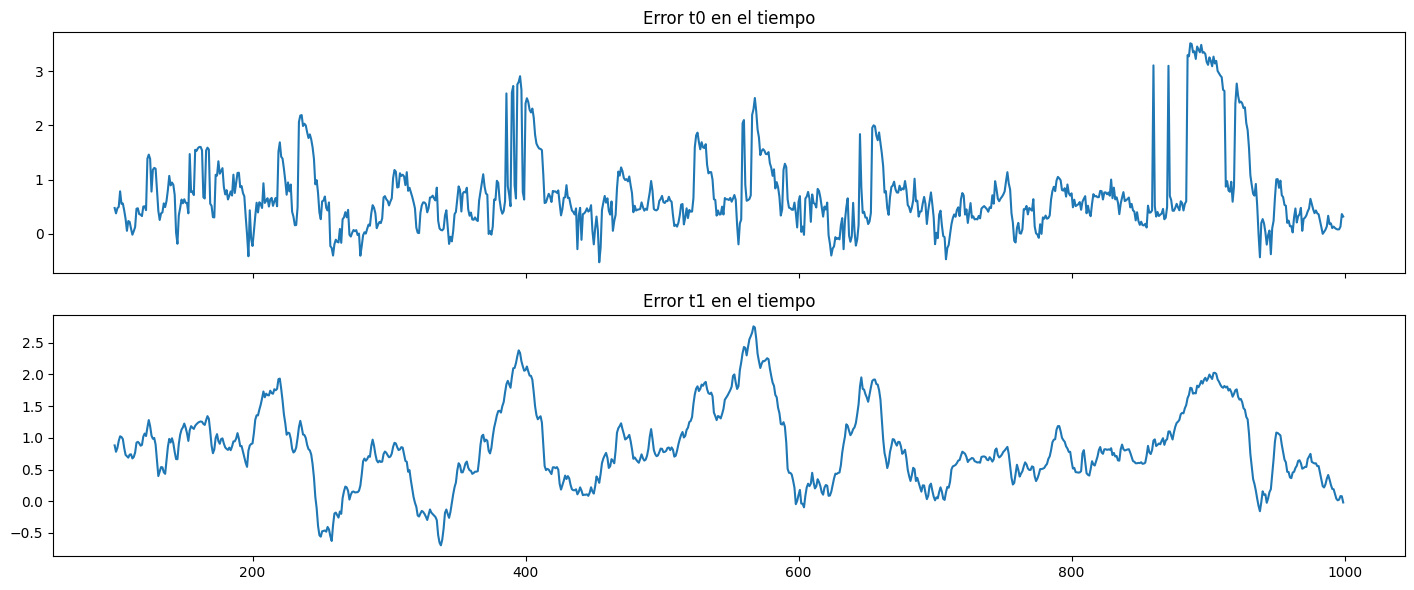

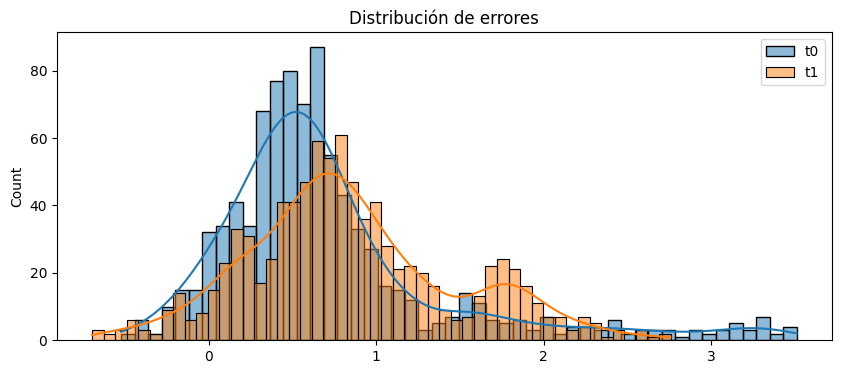

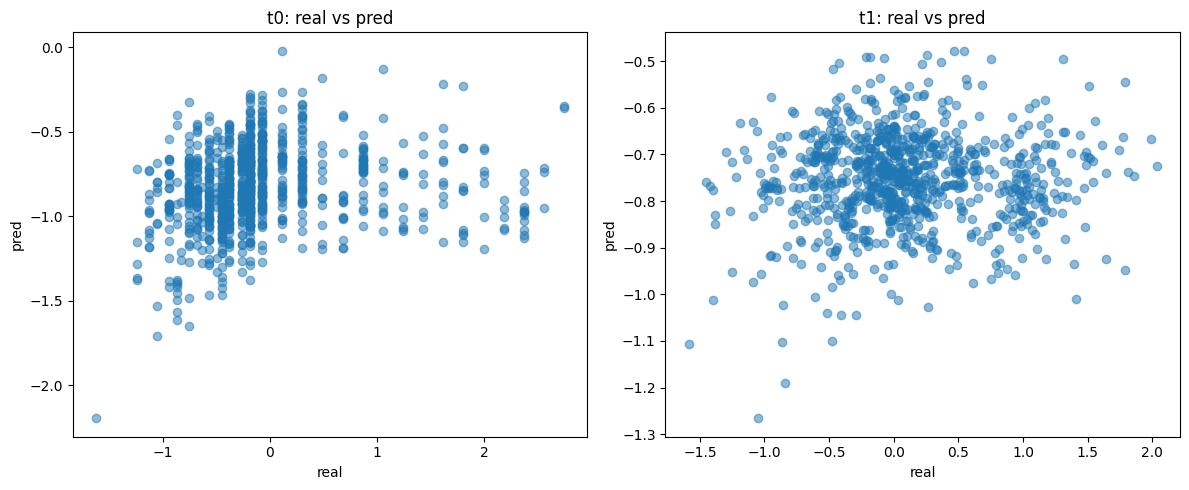

{'t0': 0.24779012518317714, 't1': 0.032001147351929514, 'weighted_pearson': 0.13989563626755333}


In [20]:
scores = arima.evaluate()
arima.qualitative_evaluation()
print(scores)

## Ensemble ARIMAx


In [37]:
from src import ARIMAEnsemble

arimaE = ARIMAEnsemble(
    panel,
    testPanel,
    orders_t0=((1,0,1), (2,0,1), (2,0,2),(3,0,3), (3,1,2), (2,2,2)),
    orders_t1=((1,0,1), (2,0,1), (2,0,2),(3,0,3), (3,1,2), (2,2,2)),
    top_k_features=12,
    min_abs_corr=0.06,
    max_pairwise_corr=0.90,
    max_features_per_member=10,
    n_bootstrap=5,
    random_state=42,
)

arimaE.fit()



/home/adrian/git_repos/LOB-predictorium/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/adrian/git_repos/LOB-predictorium/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/adrian/git_repos/LOB-predictorium/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/adrian/git_repos/LOB-predictorium/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likeliho

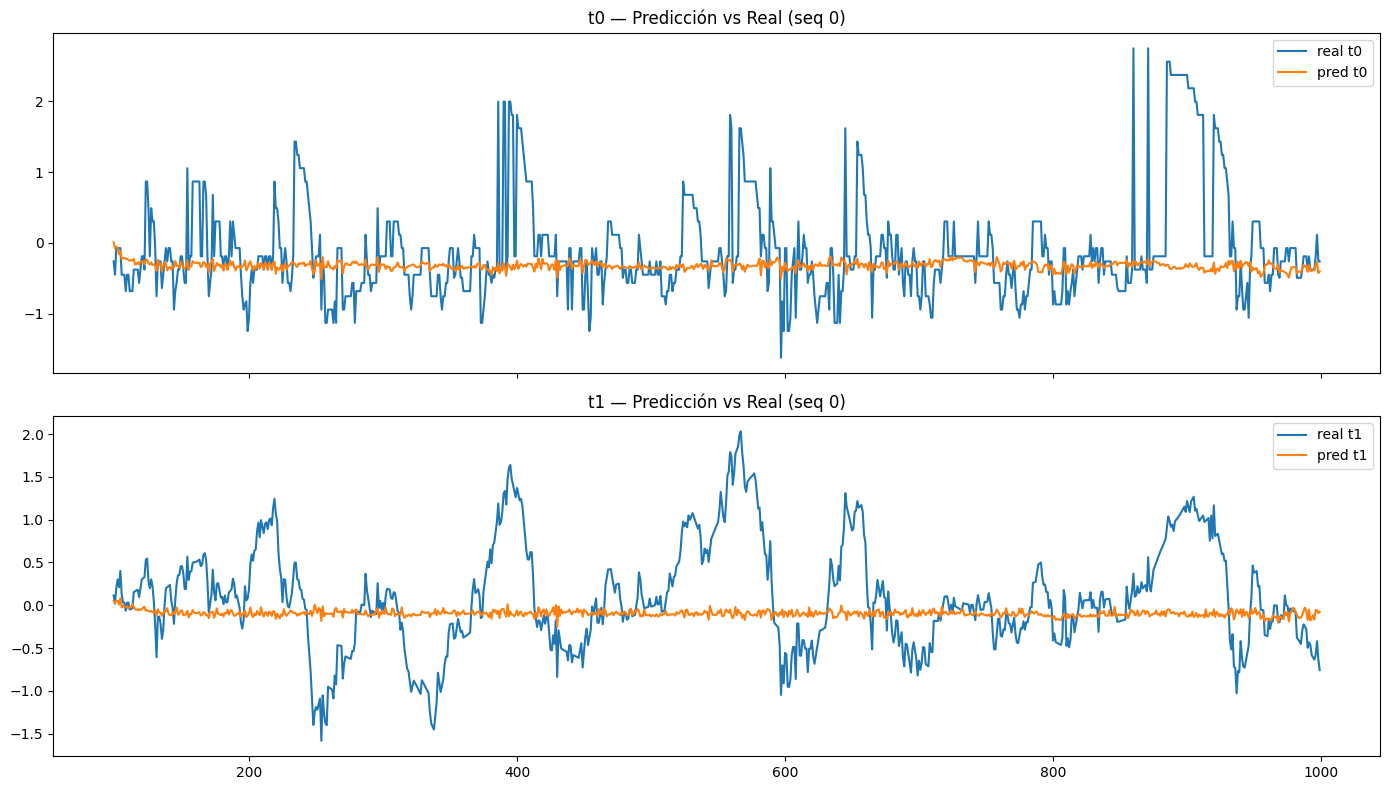

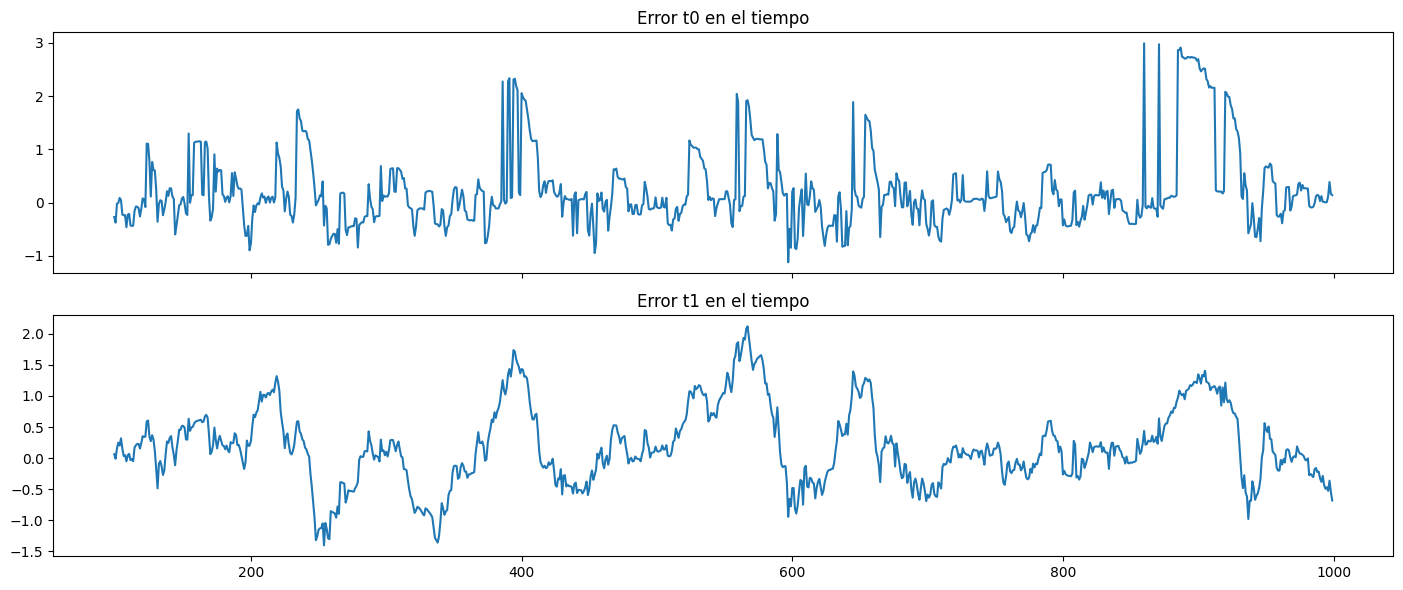

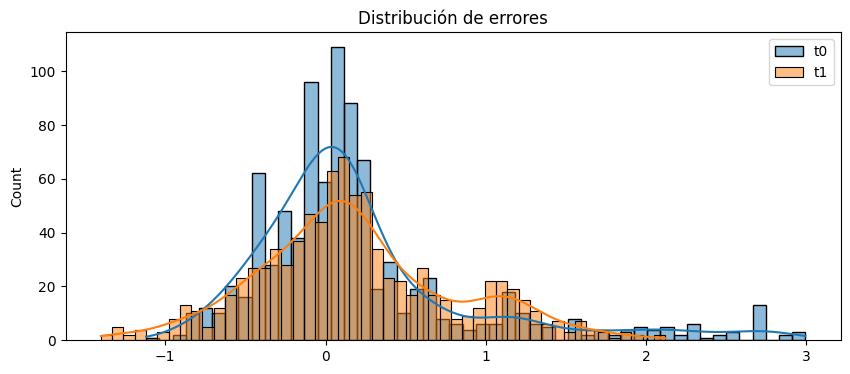

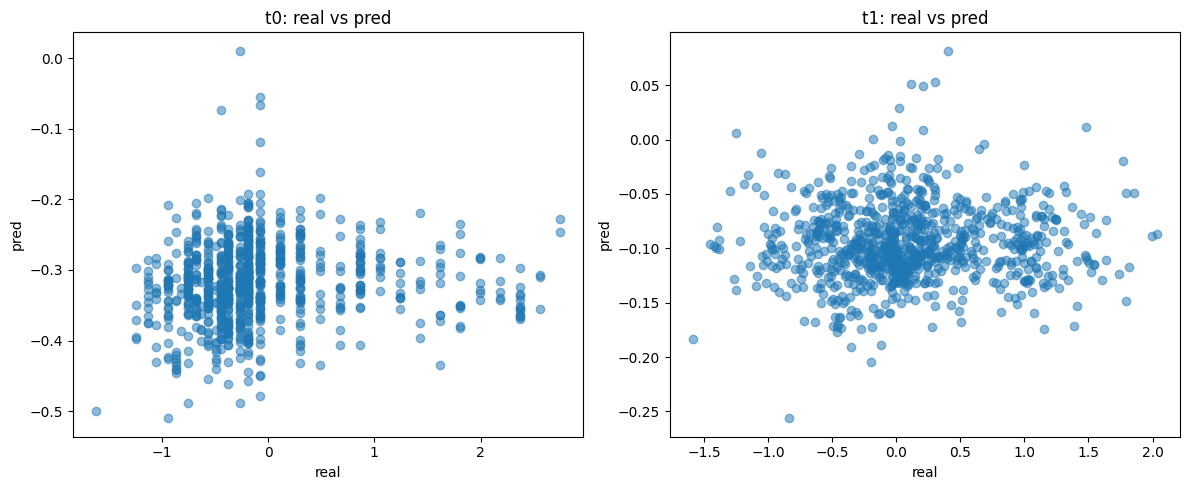

{'t0': 0.10017792819459712, 't1': 0.02359614627883767, 'weighted_pearson': 0.061887037236717395}


In [38]:
scores = arimaE.evaluate()
arimaE.qualitative_evaluation()
print(scores)

## GRU + Attention

In [8]:
from src import TorchSequenceModel

In [ ]:
model = TorchSequenceModel(
    train_path=STORAGE_PATH + "/train.parquet",
    test_path=STORAGE_PATH + "/valid.parquet",
    window_size=75,
    hidden_dim=256,
    num_heads=16,
    lr=1e-3,
    epochs=3,
    device="cuda",
)

model.fit(batch_size=256, num_workers=0, prediction_only=False)

Epoch 1/3: 62batch [00:16,  3.72batch/s, loss_t0=1.48, loss_t1=3.26]


KeyboardInterrupt: 

In [ ]:
model.plot_loss_curve()

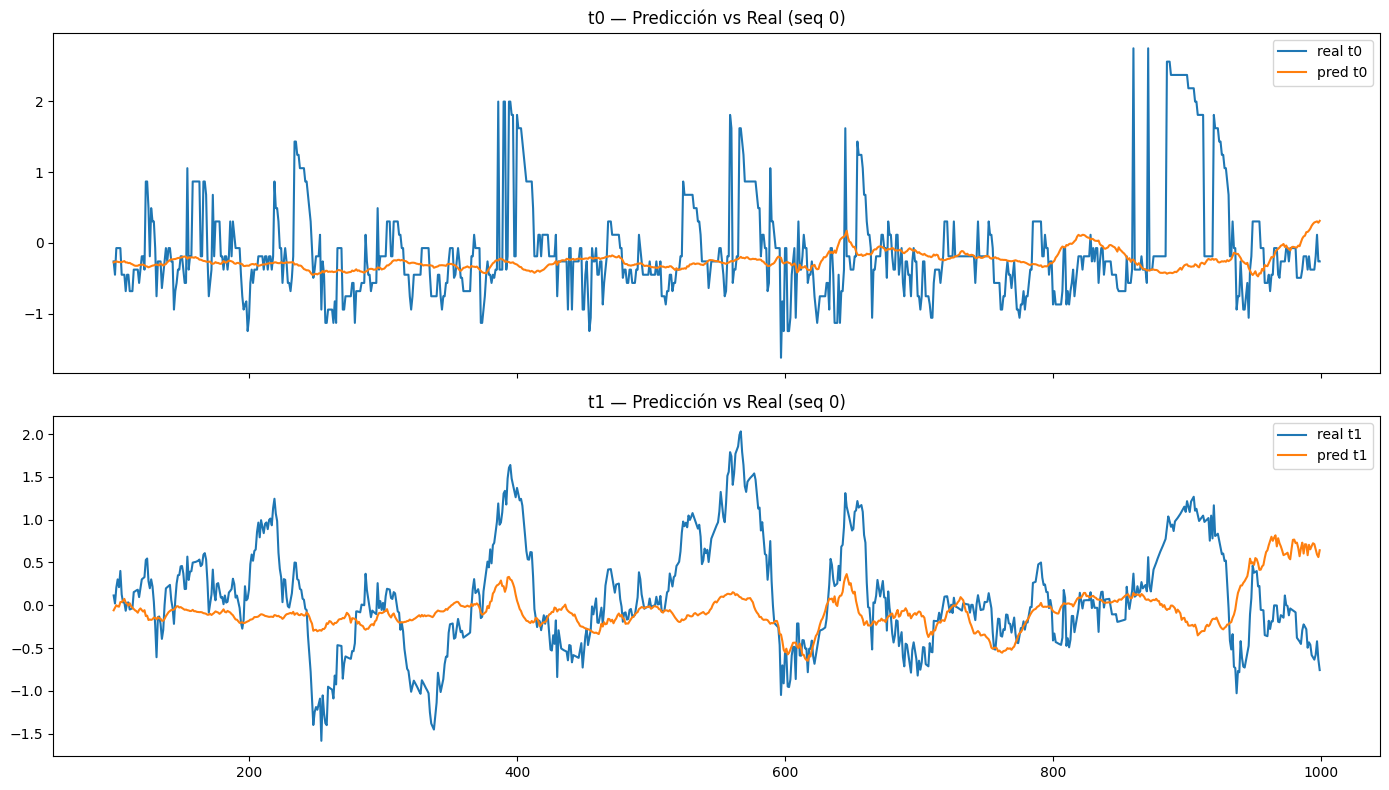

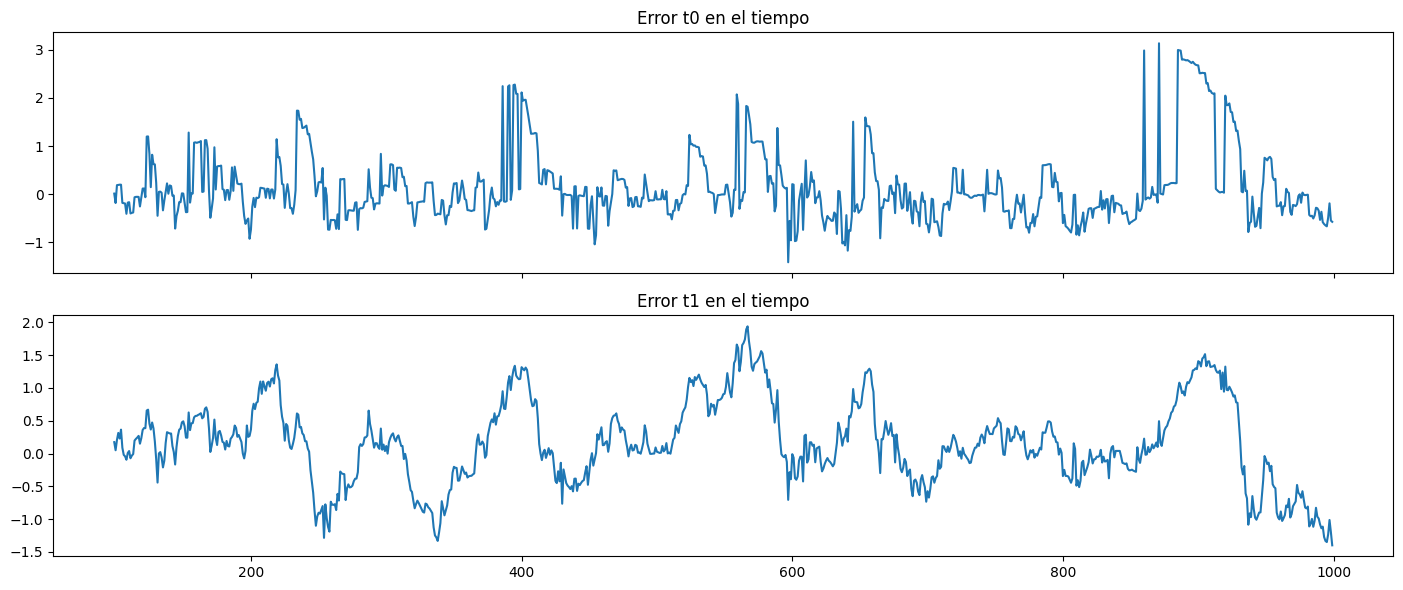

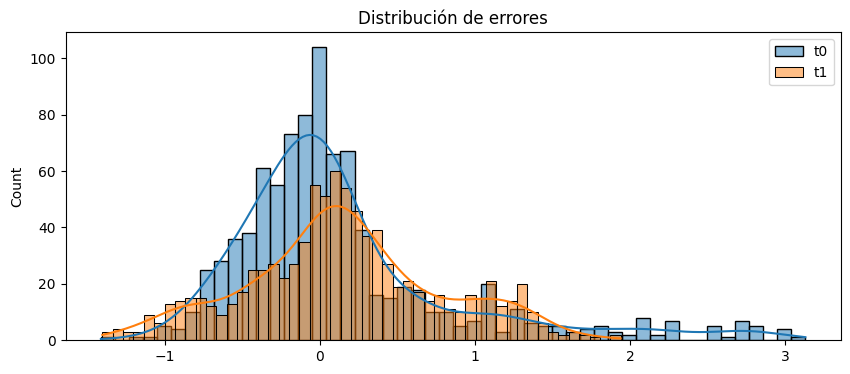

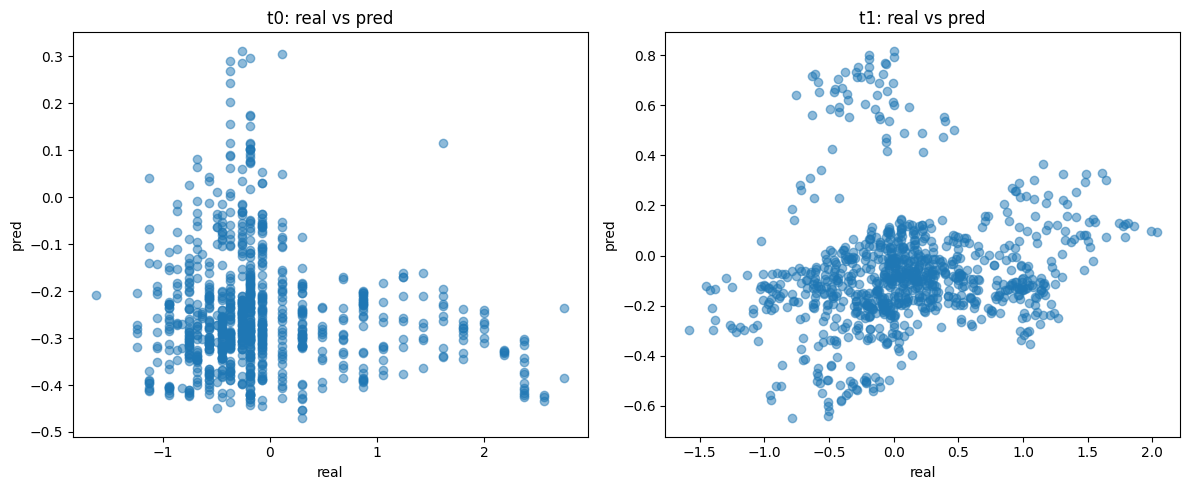

{'t0': 0.0590377032023128, 't1': -0.010406141965532531, 'weighted_pearson': 0.024315780618390136}


In [ ]:
scores = model.evaluate()
print(scores)